
# UKB Showcase+ — author-based academic impact figures

This notebook reads the project's full-endpoint Showcase+ parquet, rebuilds author-level data from the publication-level `authors` field, and exports three author-impact analyses.



1. **Author-entry cohort contribution profile** — best main-paper replacement for Fig. 3a.
2. **Author impact portfolio map** — visually rich view of different forms of author influence.
3. **Influential-author fingerprint heatmap** — dense supplementary profile of leading contributors.




## 0. Inputs expected

The notebook uses the project-wide Showcase+ publication parquet configured in `src/utils/shared_paths.py`:

```text
data/showcase/showcase+/showcase_plus_all_endpoint.parquet
```

The parquet should contain at least:

- a Dimensions publication identifier column, `id`;
- a publication year column, `year`;
- a citation count column, `times_cited`;
- an author metadata column, `authors`.

Optional columns include `field_citation_ratio`, `relative_citation_ratio` and `recent_citations`.


In [ ]:

# ============================================================
# 1. Setup, paths and plotting style
# ============================================================

from pathlib import Path
import os
import sys
import re
import ast
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter, FuncFormatter

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

# -------------------------
# Repository root and project-standard paths
# -------------------------
ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src" / "utils").is_dir()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Run this notebook from within the project repository.")

sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P

ROOT = P.bootstrap()
INPUT_PARQUET = P.SHOWCASE_PLUS
OUT_DIR = P.OUTPUT
# One slug, five places: this is an 03_academic_impact notebook, so its figures
# and tables belong under the 03 slug. They were written to `05_author_impact/`
# until 2026-08-26; anything still in those directories is superseded output.
FIG_DIR = P.FIG_ACADEMIC_IMPACT
TABLE_DIR = P.OUTPUT_TABLES / "03_academic_impact"
TEXT_DIR = P.OUTPUT / "paper_text" / "03_academic_impact"
for d in [OUT_DIR, FIG_DIR, TABLE_DIR, TEXT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Coherent colour palette
# -------------------------
COLOUR = {
    "ink": "#1F2933",
    "blue_dark": "#1F4E79",
    "blue": "#2F7FB8",
    "blue_mid": "#6BAED6",
    "blue_light": "#DCEAF6",
    "teal": "#1B9E9A",
    "green": "#59A14F",
    "gold": "#E3B23C",
    "orange": "#D97A32",
    "purple": "#6F4E9B",
    "grey_dark": "#3A3A3A",
    "grey": "#777777",
    "grey_mid": "#B8B8B8",
    "grey_light": "#EAEAEA",
    "almost_white": "#F8FAFC",
}

blue_cmap = LinearSegmentedColormap.from_list(
    "ukb_blues",
    ["#F7FBFF", "#DCEAF6", "#9ECAE1", "#4292C6", "#1F4E79"],
)
cohort_palette = ["#DCEAF6", "#9ECAE1", "#4292C6", "#1F4E79"]

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "axes.titlesize": 13,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.4,
    "ytick.labelsize": 9.4,
    "legend.fontsize": 8.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#333333",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def save_fig(fig, stem):
    """Save a figure in paper-friendly formats."""
    for ext in ["pdf", "svg", "png"]:
        fig.savefig(
            FIG_DIR / f"{stem}.{ext}",
            bbox_inches="tight",
            facecolor="white",
            dpi=600,
        )
    print("Saved:", FIG_DIR / f"{stem}.pdf")

print("ROOT:", ROOT)
print("Input:", INPUT_PARQUET)
print("Output:", OUT_DIR)


Mounted at /content/drive


In [ ]:

# ============================================================
# 2. Robust helpers: column inference and author parsing
# ============================================================

def norm_name_for_col(x):
    return re.sub(r"[^a-z0-9]+", "_", str(x).lower()).strip("_")


def infer_col(df, candidates):
    """Infer a column from a list of candidate names using exact and fuzzy matching."""
    norm = {norm_name_for_col(c): c for c in df.columns}
    for cand in candidates:
        key = norm_name_for_col(cand)
        if key in norm:
            return norm[key]
    for cand in candidates:
        key = norm_name_for_col(cand)
        for n, orig in norm.items():
            if key and (key in n or n in key):
                return orig
    return None


def clean_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def normalise_title(x):
    x = clean_str(x).lower()
    x = re.sub(r"[^a-z0-9]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def safe_json_loads(x):
    """Parse JSON-like cells from Dimensions exports. Handles lists, dicts, JSON strings and Python literal strings."""
    if x is None:
        return None
    if isinstance(x, (list, dict)):
        return x
    if isinstance(x, float) and pd.isna(x):
        return None
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in ["nan", "none", "null"]:
        return None
    for parser in [json.loads, ast.literal_eval]:
        try:
            return parser(s)
        except Exception:
            pass
    return s


def mode_or_blank(s):
    s = pd.Series(s).dropna().astype(str)
    s = s[s.str.strip() != ""]
    if s.empty:
        return ""
    m = s.mode()
    return m.iloc[0] if len(m) else s.iloc[0]


def pct_rank_safe(s):
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan).astype(float)
    if s.notna().sum() == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    if s.nunique(dropna=True) <= 1:
        return pd.Series(np.ones(len(s)) * 0.5, index=s.index)
    return s.rank(pct=True, method="average").fillna(0)


def h_index_from_citations(citations):
    vals = sorted([int(float(c)) for c in citations if not pd.isna(c)], reverse=True)
    h = 0
    for i, c in enumerate(vals, start=1):
        if c >= i:
            h = i
        else:
            break
    return h


def i10_index_from_citations(citations):
    vals = [float(c) for c in citations if not pd.isna(c)]
    return int(sum(c >= 10 for c in vals))


def winsorise(s, lo=0.01, hi=0.99):
    s = pd.Series(s).astype(float).replace([np.inf, -np.inf], np.nan)
    if s.notna().sum() < 10:
        return s
    return s.clip(s.quantile(lo), s.quantile(hi))


In [ ]:

# ============================================================
# 3. Load the Showcase+ full-endpoint publication parquet
# ============================================================

if not INPUT_PARQUET.exists():
    raise FileNotFoundError(f"Showcase+ publication parquet not found: {INPUT_PARQUET}")

showcase_dim = pd.read_parquet(INPUT_PARQUET)
print("Loaded Showcase+ full-endpoint parquet:", INPUT_PARQUET)
print("Shape:", showcase_dim.shape)
print("Columns preview:", list(showcase_dim.columns[:30]))

# Infer key columns.
ID_COL = infer_col(showcase_dim, ["id", "publication_id", "dimensions_id", "doi"])
YEAR_COL = infer_col(showcase_dim, ["year", "publication_year", "pub_year"])
CIT_COL = infer_col(showcase_dim, ["times_cited", "citation_count", "cited_by_count"])
RECENT_CIT_COL = infer_col(showcase_dim, ["recent_citations", "recent_citation_count"])
FCR_COL = infer_col(showcase_dim, ["field_citation_ratio"])
RCR_COL = infer_col(showcase_dim, ["relative_citation_ratio"])
AUTHOR_COL = infer_col(showcase_dim, ["authors", "author_list"])
TITLE_COL = infer_col(showcase_dim, ["title", "publication_title"])
VENUE_COL = infer_col(showcase_dim, ["source_title", "journal_title_raw", "journal", "journal_title"])

required = {"ID_COL": ID_COL, "YEAR_COL": YEAR_COL, "CIT_COL": CIT_COL, "AUTHOR_COL": AUTHOR_COL}
print("\nInferred columns")
for k, v in required.items():
    print(f"  {k}: {v}")
print("  RECENT_CIT_COL:", RECENT_CIT_COL)
print("  FCR_COL:", FCR_COL)
print("  RCR_COL:", RCR_COL)
print("  TITLE_COL:", TITLE_COL)
print("  VENUE_COL:", VENUE_COL)

missing = [k for k, v in required.items() if v is None]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Save an input manifest for reproducibility.
manifest = pd.DataFrame({
    "item": ["input_parquet", "ID_COL", "YEAR_COL", "CIT_COL", "AUTHOR_COL", "FCR_COL", "RCR_COL", "RECENT_CIT_COL"],
    "value": [str(INPUT_PARQUET), ID_COL, YEAR_COL, CIT_COL, AUTHOR_COL, FCR_COL, RCR_COL, RECENT_CIT_COL],
})
manifest.to_csv(TABLE_DIR / "input_manifest_author_impact_notebook.csv", index=False)
display(manifest)


Loaded enriched metadata: [previous-local-project]/showcase_plus_analysis_v2/tables/showcase_plus_dimensions_enriched.csv
Shape: (21581, 64)
Columns preview: ['showcase_id', 'id', 'title', 'abstract', 'year', 'label', '_dimensions_id_norm', '_doi_norm', '_pmid_norm', '_pmcid_norm', '_internal_id_norm', '_title_norm', '_year_norm', 'source_three_model_true_agreement', 'source_showcase_groundtruth_positive', 'showcase_source', '_source_priority', 'qwen_label', 'qwen_parse_ok', 'qwen_raw_output', 'llama3_8b_label', 'llama3_8b_parse_ok', 'llama3_8b_raw_output', 'mistral_7b_label', 'mistral_7b_parse_ok', 'mistral_7b_raw_output', 'year_int', 'qwen_true', 'qwen_false', 'llama3_8b_true']
Loaded base Showcase+ table: [previous-local-project]/showcase_plus_analysis_v2/showcase_plus.csv (21581, 40)

Inferred columns
  ID_COL: showcase_id
  YEAR_COL: analysis_year
  CIT_COL: dim_times_cited
  AUTHOR_COL: dim_authors
  RECENT_CIT_COL: None
  FCR_COL: dim_field_citation_ratio
  RCR_COL: dim_relative

,item,value
0,enriched_path,[previous-local-project]/...
1,base_path,[previous-local-project]/...
2,ID_COL,showcase_id
3,YEAR_COL,analysis_year
4,CIT_COL,dim_times_cited
5,AUTHOR_COL,dim_authors
6,FCR_COL,dim_field_citation_ratio
7,RCR_COL,dim_relative_citation_ratio
8,RECENT_CIT_COL,None


In [ ]:

# ============================================================
# 4. Prepare paper-level impact table
# ============================================================

paper = showcase_dim.copy()
paper = paper.drop_duplicates(subset=[ID_COL]).copy()

paper["paper_id"] = paper[ID_COL].astype(str)
paper["year_num"] = pd.to_numeric(paper[YEAR_COL], errors="coerce")
paper["times_cited_num"] = pd.to_numeric(paper[CIT_COL], errors="coerce").fillna(0)

if RECENT_CIT_COL is not None:
    paper["recent_citations_num"] = pd.to_numeric(paper[RECENT_CIT_COL], errors="coerce")
else:
    paper["recent_citations_num"] = np.nan

if FCR_COL is not None:
    paper["field_citation_ratio_num"] = pd.to_numeric(paper[FCR_COL], errors="coerce")
else:
    paper["field_citation_ratio_num"] = np.nan

if RCR_COL is not None:
    paper["relative_citation_ratio_num"] = pd.to_numeric(paper[RCR_COL], errors="coerce")
else:
    paper["relative_citation_ratio_num"] = np.nan

# Use 2026 because your current draft/notebook treats 2026 as the incomplete current year.
# Edit if your Dimensions citation snapshot was taken in another year.
CITATION_AS_OF_YEAR = 2026
paper["citation_age_years"] = (CITATION_AS_OF_YEAR - paper["year_num"] + 1).clip(lower=1)
paper["citations_per_year"] = paper["times_cited_num"] / paper["citation_age_years"]

# Choose the best normalised impact metric available.
if paper["field_citation_ratio_num"].notna().sum() >= 100:
    IMPACT_METRIC = "field_citation_ratio_num"
    IMPACT_LABEL = "Field Citation Ratio"
    IMPACT_SHORT = "FCR"
elif paper["relative_citation_ratio_num"].notna().sum() >= 100:
    IMPACT_METRIC = "relative_citation_ratio_num"
    IMPACT_LABEL = "Relative Citation Ratio"
    IMPACT_SHORT = "RCR"
else:
    IMPACT_METRIC = "citations_per_year"
    IMPACT_LABEL = "citations per year"
    IMPACT_SHORT = "annualised citations"

paper["impact_metric"] = pd.to_numeric(paper[IMPACT_METRIC], errors="coerce")

# Exclude invalid years and keep 2014–2025 for interpretable impact analysis.
# 2026 is incomplete and should not drive main figures.
paper_main = paper[
    paper["year_num"].notna()
    & (paper["year_num"] >= 2014)
    & (paper["year_num"] <= 2025)
    & paper["impact_metric"].notna()
].copy()
paper_main["year_num"] = paper_main["year_num"].astype(int)

TOP_DECILE_THRESHOLD = np.nanpercentile(paper_main["impact_metric"], 90)
paper_main["is_top_decile_impact"] = paper_main["impact_metric"] >= TOP_DECILE_THRESHOLD

print("Paper table:", paper.shape)
print("Main impact table:", paper_main.shape)
print("Impact metric:", IMPACT_LABEL)
print("Top-decile threshold:", TOP_DECILE_THRESHOLD)

display(paper_main[["paper_id", "year_num", "times_cited_num", "citations_per_year", "impact_metric", "is_top_decile_impact"]].head())


Paper table: (21581, 73)
Main impact table: (16679, 74)
Impact metric: Field Citation Ratio
Top-decile threshold: 19.8


,paper_id,year_num,times_cited_num,citations_per_year,impact_metric,is_top_decile_impact
0,dimensions:pub.1000169743,2014,222.0,17.076923,33.00,True
1,dimensions:pub.1000305094,2016,55.0,5.000000,8.82,False
2,dimensions:pub.1001609820,2016,73.0,6.636364,23.06,True
3,dimensions:pub.1001822430,2016,16.0,1.454545,4.89,False
4,dimensions:pub.1001987017,2014,0.0,0.000000,0.00,False


In [ ]:

# ============================================================
# 5. Explode Dimensions authors and build author-level metrics
# ============================================================

def normalise_authors_cell(cell):
    """Return a list of normalised author dictionaries from a Dimensions author cell."""
    obj = safe_json_loads(cell)
    if obj is None:
        return []

    # Some exports store a single dict.
    if isinstance(obj, dict):
        obj = [obj]

    # If parsing failed and we have a string, split conservatively.
    if isinstance(obj, str):
        parts = [p.strip() for p in re.split(r";|\|", obj) if p.strip()]
        return [{"name": p, "first_name": p.split()[0] if p.split() else "", "last_name": "", "researcher_id": ""} for p in parts]

    if not isinstance(obj, list):
        return []

    authors = []
    for a in obj:
        if isinstance(a, dict):
            first = clean_str(a.get("first_name", a.get("first", "")))
            last = clean_str(a.get("last_name", a.get("last", "")))
            name = clean_str(a.get("name", " ".join([first, last]).strip()))
            rid = clean_str(a.get("researcher_id", ""))
            if not rid and isinstance(a.get("researcher_ids"), list) and a.get("researcher_ids"):
                rid = clean_str(a.get("researcher_ids")[0])
            if not first and name:
                first = name.split()[0]
            authors.append({
                "name": name,
                "first_name": first,
                "last_name": last,
                "researcher_id": rid,
            })
        elif isinstance(a, str):
            name = a.strip()
            authors.append({
                "name": name,
                "first_name": name.split()[0] if name else "",
                "last_name": "",
                "researcher_id": "",
            })
    return [a for a in authors if a.get("name") or a.get("researcher_id")]

# Join only the columns needed for author-level analysis.
source_cols = [ID_COL, AUTHOR_COL, YEAR_COL, CIT_COL]
for optional in [RECENT_CIT_COL, FCR_COL, RCR_COL, TITLE_COL, VENUE_COL]:
    if optional is not None and optional not in source_cols:
        source_cols.append(optional)
source_cols = [c for c in source_cols if c is not None and c in showcase_dim.columns]

# Map paper-level values from paper_main for consistency.
paper_lookup = paper_main[[
    "paper_id", "year_num", "times_cited_num", "recent_citations_num",
    "field_citation_ratio_num", "relative_citation_ratio_num",
    "citations_per_year", "impact_metric", "is_top_decile_impact"
]].copy()

raw = showcase_dim[source_cols].copy()
raw["paper_id"] = raw[ID_COL].astype(str)
raw = raw.merge(paper_lookup, on="paper_id", how="inner")

# Optional source route if available in the publication parquet.
if "source_route" in showcase_dim.columns:
    raw["source_route"] = showcase_dim["source_route"]

# Explode authors.
author_rows = []
for _, r in tqdm(raw.iterrows(), total=len(raw), desc="Exploding authors"):
    authors = normalise_authors_cell(r.get(AUTHOR_COL))
    if not authors:
        continue
    n_authors = len(authors)
    for pos, a in enumerate(authors, start=1):
        rid = clean_str(a.get("researcher_id", ""))
        name = clean_str(a.get("name", ""))
        author_key = rid if rid.startswith("ur.") else normalise_title(name)
        if not author_key:
            continue
        author_rows.append({
            "paper_id": r["paper_id"],
            "author_position": pos,
            "n_authors": n_authors,
            "is_first_author": pos == 1,
            "is_last_author": pos == n_authors,
            "author_name": name,
            "first_name": clean_str(a.get("first_name", "")),
            "last_name": clean_str(a.get("last_name", "")),
            "researcher_id": rid,
            "author_key": author_key,
            "year": int(r["year_num"]),
            "times_cited": float(r["times_cited_num"]),
            "recent_citations": r.get("recent_citations_num", np.nan),
            "field_citation_ratio": r.get("field_citation_ratio_num", np.nan),
            "relative_citation_ratio": r.get("relative_citation_ratio_num", np.nan),
            "citations_per_year": r.get("citations_per_year", np.nan),
            "impact_metric": r.get("impact_metric", np.nan),
            "is_top_decile_impact": bool(r.get("is_top_decile_impact", False)),
            "source_route": r.get("source_route", "") if "source_route" in raw.columns else "",
        })

author_long = pd.DataFrame(author_rows)
if author_long.empty:
    raise ValueError("No authors could be parsed from the author column.")

# Deduplicate within paper-author in case of duplicated names/IDs.
author_paper = author_long.drop_duplicates(["author_key", "paper_id"]).copy()
author_paper["author_name_clean"] = author_paper["author_name"].fillna("").astype(str).str.strip()

# Fractional credit: each co-author receives 1/n_authors paper credit and citations/n_authors citation credit.
author_paper["fractional_paper_credit"] = 1 / author_paper["n_authors"].clip(lower=1)
author_paper["fractional_citation_credit"] = author_paper["times_cited"] / author_paper["n_authors"].clip(lower=1)
author_paper["fractional_top_decile_credit"] = np.where(
    author_paper["is_top_decile_impact"],
    1 / author_paper["n_authors"].clip(lower=1),
    0,
)
author_paper["leadership_author_credit"] = author_paper["is_first_author"].astype(int) + author_paper["is_last_author"].astype(int)

# Author-level summary.
base = (
    author_paper.groupby("author_key")
    .agg(
        author_name=("author_name_clean", mode_or_blank),
        researcher_id=("researcher_id", mode_or_blank),
        showcase_paper_count=("paper_id", "nunique"),
        fractional_paper_credit=("fractional_paper_credit", "sum"),
        total_dataset_citations=("times_cited", "sum"),
        fractional_citation_credit=("fractional_citation_credit", "sum"),
        mean_dataset_citations=("times_cited", "mean"),
        median_dataset_citations=("times_cited", "median"),
        mean_field_citation_ratio=("field_citation_ratio", "mean"),
        median_field_citation_ratio=("field_citation_ratio", "median"),
        mean_relative_citation_ratio=("relative_citation_ratio", "mean"),
        median_citations_per_year=("citations_per_year", "median"),
        mean_impact_metric=("impact_metric", "mean"),
        median_impact_metric=("impact_metric", "median"),
        top_decile_paper_count=("is_top_decile_impact", "sum"),
        fractional_top_decile_credit=("fractional_top_decile_credit", "sum"),
        first_author_paper_count=("is_first_author", "sum"),
        last_author_paper_count=("is_last_author", "sum"),
        leadership_author_credit=("leadership_author_credit", "sum"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

metric_rows = []
for key, g in author_paper.groupby("author_key"):
    cites = pd.to_numeric(g["times_cited"], errors="coerce").fillna(0).tolist()
    metric_rows.append({
        "author_key": key,
        "showcase_h_index": h_index_from_citations(cites),
        "showcase_i10_index": i10_index_from_citations(cites),
    })
metrics = pd.DataFrame(metric_rows)
author_summary = base.merge(metrics, on="author_key", how="left")

author_summary["active_span_years"] = author_summary["last_year"] - author_summary["first_year"] + 1
author_summary["leadership_share"] = (
    author_summary["first_author_paper_count"] + author_summary["last_author_paper_count"]
) / author_summary["showcase_paper_count"].clip(lower=1)
author_summary["top_decile_share"] = author_summary["top_decile_paper_count"] / author_summary["showcase_paper_count"].clip(lower=1)

# Entry cohorts for the main contribution-profile figure.
def assign_entry_cohort(y):
    if pd.isna(y):
        return np.nan
    y = int(y)
    if 2014 <= y <= 2016:
        return "2014–2016\nfoundational entrants"
    if 2017 <= y <= 2019:
        return "2017–2019\nexpansion entrants"
    if 2020 <= y <= 2022:
        return "2020–2022\nconsolidation entrants"
    if 2023 <= y <= 2025:
        return "2023–2025\nrecent entrants"
    return np.nan

cohort_order = [
    "2014–2016\nfoundational entrants",
    "2017–2019\nexpansion entrants",
    "2020–2022\nconsolidation entrants",
    "2023–2025\nrecent entrants",
]
author_summary["entry_cohort"] = author_summary["first_year"].apply(assign_entry_cohort)

# Attach entry cohort back to each paper-author row.
author_paper = author_paper.merge(
    author_summary[["author_key", "entry_cohort"]],
    on="author_key",
    how="left",
)

# Composite influence score: deliberately excludes recent citations if absent/zero for all rows.
score_terms = {
    "total citations": 0.26 * pct_rank_safe(np.log1p(author_summary["total_dataset_citations"])),
    "fractional citations": 0.20 * pct_rank_safe(np.log1p(author_summary["fractional_citation_credit"])),
    "Showcase+ h-index": 0.20 * pct_rank_safe(author_summary["showcase_h_index"]),
    f"mean {IMPACT_SHORT}": 0.16 * pct_rank_safe(author_summary["mean_impact_metric"]),
    "leadership authorships": 0.12 * pct_rank_safe(author_summary["leadership_author_credit"]),
    "active span": 0.06 * pct_rank_safe(author_summary["active_span_years"]),
}
author_summary["ukb_influence_score"] = 100 * sum(score_terms.values())

author_summary = author_summary.sort_values(
    ["ukb_influence_score", "showcase_h_index", "total_dataset_citations"],
    ascending=False,
).reset_index(drop=True)

# Save full inputs generated by this notebook.
author_long.to_csv(TABLE_DIR / "author_long_all_parsed_rows.csv", index=False)
author_paper.to_csv(TABLE_DIR / "author_paper_fractional_credit_table.csv", index=False)
author_summary.to_csv(TABLE_DIR / "author_summary_with_impact_metrics.csv", index=False)
author_summary.sort_values("showcase_paper_count", ascending=False).to_csv(TABLE_DIR / "top_authors_by_most_ukb_papers.csv", index=False)
author_summary.sort_values("ukb_influence_score", ascending=False).to_csv(TABLE_DIR / "top_authors_by_ukb_influence_score.csv", index=False)
try:
    author_summary.to_excel(TABLE_DIR / "author_summary_with_impact_metrics.xlsx", index=False)
except Exception as e:
    print("Excel export skipped:", e)

print("Author long rows:", author_long.shape)
print("Author-paper rows:", author_paper.shape)
print("Author summary:", author_summary.shape)
print("Recurrent authors with >=5 papers:", int((author_summary["showcase_paper_count"] >= 5).sum()))

display(author_summary.head(25))


Exploding authors:   0%|          | 0/16679 [00:00<?, ?it/s]

Author long rows: (205023, 19)
Author-paper rows: (203758, 25)
Author summary: (66854, 29)
Recurrent authors with >=5 papers: 8555


,author_key,author_name,researcher_id,showcase_paper_count,fractional_paper_credit,total_dataset_citations,fractional_citation_credit,mean_dataset_citations,median_dataset_citations,mean_field_citation_ratio,median_field_citation_ratio,mean_relative_citation_ratio,median_citations_per_year,mean_impact_metric,median_impact_metric,top_decile_paper_count,fractional_top_decile_credit,first_author_paper_count,last_author_paper_count,leadership_author_credit,first_year,last_year,showcase_h_index,showcase_i10_index,active_span_years,leadership_share,top_decile_share,entry_cohort,ukb_influence_score
0,ur.0641770103.91,Rory Collins,ur.0641770103.91,43,2.718020,24193.0,1606.181951,562.627907,32.0,107.889535,7.690,23.976923,5.750000,107.889535,7.690,17,1.127735,0,4,4,2014,2024,24,30,11,0.093023,0.395349,2014–2016\nfoundational entrants,98.596703
1,ur.0627601545.87,Paul M. Matthews,ur.0627601545.87,52,5.133639,20867.0,1093.157300,401.288462,33.5,78.443846,7.770,18.326667,4.842857,78.443846,7.770,14,0.664220,1,9,10,2015,2024,28,33,10,0.192308,0.269231,2014–2016\nfoundational entrants,98.583106
2,ur.010254226477.98,Cathie Sudlow,ur.010254226477.98,66,5.722479,26050.0,1661.836522,394.696970,46.0,69.244545,9.380,14.249318,5.312500,69.244545,9.380,23,1.800600,1,17,18,2014,2024,36,48,11,0.272727,0.348485,2014–2016\nfoundational entrants,98.568852
3,ur.0577003004.68,Naomi Allen,ur.0577003004.68,95,11.547227,32601.0,2233.834445,343.168421,22.0,63.671789,5.340,14.565763,3.333333,63.671789,5.340,22,2.105634,4,19,23,2014,2024,37,61,11,0.242105,0.231579,2014–2016\nfoundational entrants,98.511443
4,ur.01225067535.64,Olivier Delaneau,ur.01225067535.64,24,3.699536,13191.0,849.386370,549.625000,18.5,87.086667,5.405,30.598889,4.100000,87.086667,5.405,9,0.967949,4,10,14,2015,2024,14,14,10,0.583333,0.375000,2014–2016\nfoundational entrants,98.452763
5,ur.014735204720.83,Jonathan Marchini,ur.014735204720.83,48,5.452453,20433.0,1138.742035,425.687500,43.5,66.806042,10.845,21.571818,8.651786,66.806042,10.845,16,1.044215,0,14,14,2015,2024,26,31,10,0.291667,0.333333,2014–2016\nfoundational entrants,98.437356
6,ur.01371335603.13,Peter Donnelly,ur.01371335603.13,16,1.513901,11244.0,667.681256,702.750000,92.0,121.383125,28.370,32.067143,14.128788,121.383125,28.370,9,0.723390,0,5,5,2016,2024,12,12,9,0.312500,0.562500,2014–2016\nfoundational entrants,98.365109
7,ur.01014232611.51,Paul Elliott,ur.01014232611.51,74,5.291627,24383.0,982.762313,329.500000,54.5,55.260676,12.870,12.516042,7.625000,55.260676,12.870,24,0.907958,1,9,10,2015,2024,43,58,10,0.135135,0.324324,2014–2016\nfoundational entrants,98.293760
8,ur.01125671505.27,John Gallacher,ur.01125671505.27,70,9.159059,19936.0,1082.804805,284.800000,31.5,54.848143,8.780,10.775957,5.395833,54.848143,8.780,17,0.851125,0,10,10,2014,2024,33,50,11,0.142857,0.242857,2014–2016\nfoundational entrants,98.270949
9,ur.0730724336.65,Jian Yang,ur.0730724336.65,88,8.206608,27992.0,1366.705301,318.090909,67.5,49.390909,12.165,12.183833,9.287500,49.390909,12.165,32,2.110689,3,19,22,2015,2024,46,70,10,0.250000,0.363636,2014–2016\nfoundational entrants,98.195306


entry_cohort,2014–2016\nfoundational entrants,2017–2019\nexpansion entrants,2020–2022\nconsolidation entrants,2023–2025\nrecent entrants
Unique authors,2008.00,12821.00,24470.00,27555.00
Fractional paper credit,2147.62,4533.00,5923.76,4033.91
Fractional citation credit,180911.85,228159.28,146869.44,39074.99
Top-decile paper credit,386.00,585.93,505.04,192.48
First/last-author credit,4241.00,9558.00,11911.00,7570.00


entry_cohort,2014–2016\nfoundational entrants,2017–2019\nexpansion entrants,2020–2022\nconsolidation entrants,2023–2025\nrecent entrants
Unique authors,3.0,19.2,36.6,41.2
Fractional paper credit,12.9,27.2,35.6,24.2
Fractional citation credit,30.4,38.3,24.7,6.6
Top-decile paper credit,23.1,35.1,30.3,11.5
First/last-author credit,12.7,28.7,35.8,22.7


Saved: [previous-local-project]/showcase_plus_author_impact_figures_production/figures/fig3a_author_entry_cohort_academic_impact_profile.pdf


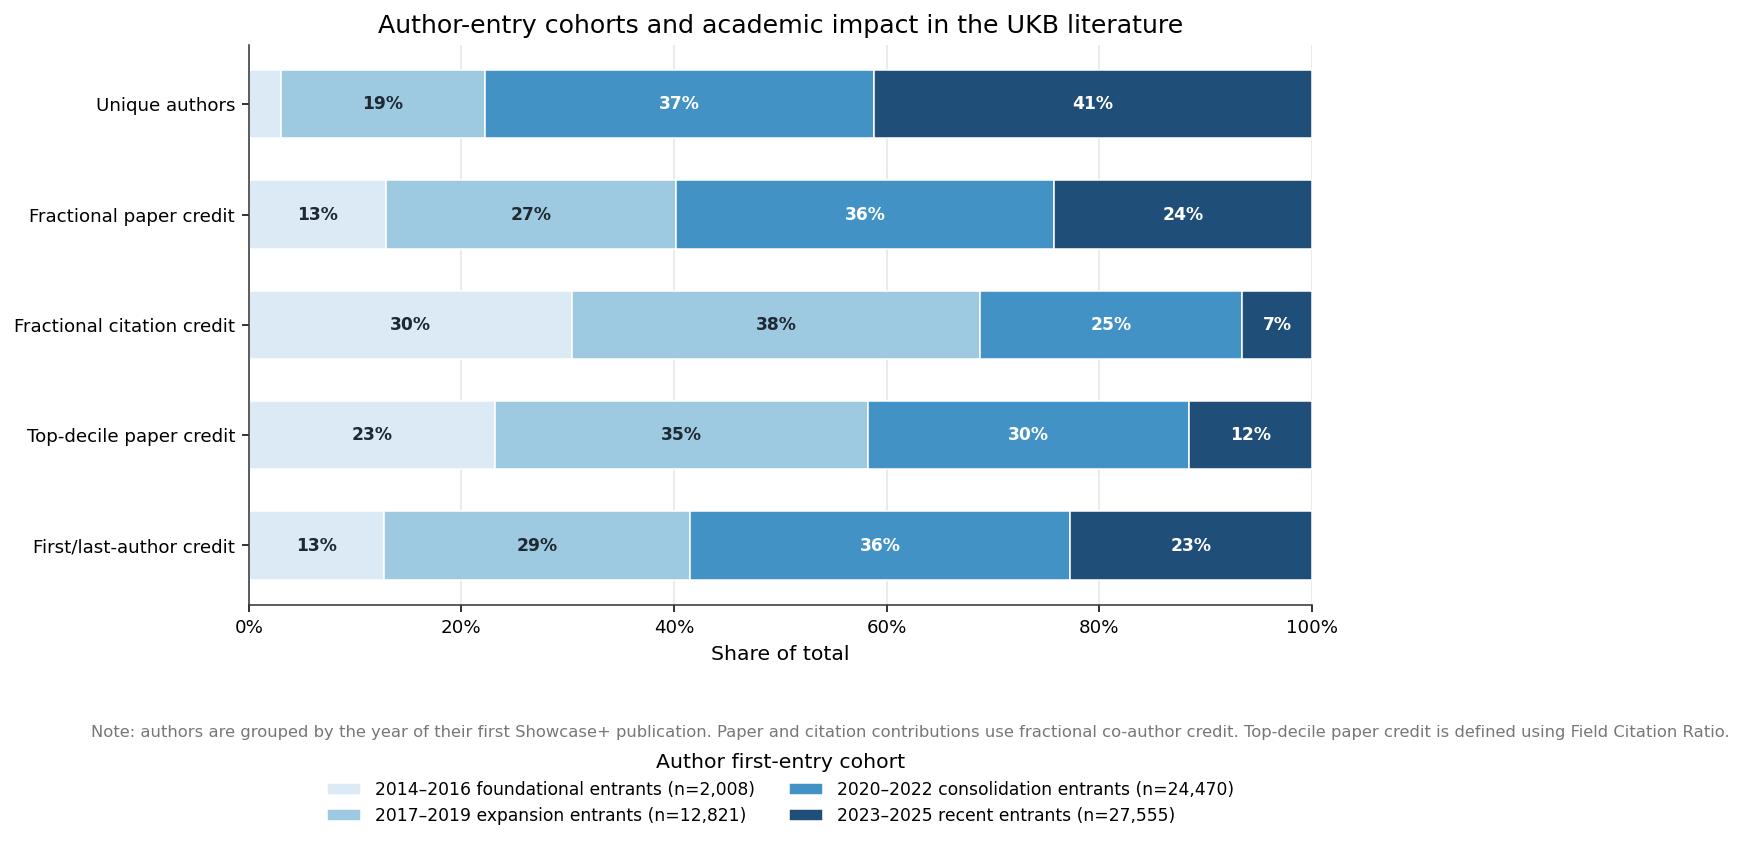

In [ ]:

# ============================================================
# 6. Candidate Fig. 3a — Author-entry cohort contribution profile
# ============================================================
# This is the recommended main-paper option.
# It asks whether UKB impact was produced mainly by early foundational contributors
# or by successive waves of researchers entering the UKB literature.

cohort_author = author_summary[author_summary["entry_cohort"].isin(cohort_order)].copy()
cohort_author["entry_cohort"] = pd.Categorical(cohort_author["entry_cohort"], categories=cohort_order, ordered=True)
cohort_paper = author_paper[author_paper["entry_cohort"].isin(cohort_order)].copy()
cohort_paper["entry_cohort"] = pd.Categorical(cohort_paper["entry_cohort"], categories=cohort_order, ordered=True)

# Aggregated shares by entry cohort.
unique_author_counts = cohort_author.groupby("entry_cohort", observed=True)["author_key"].nunique()
fractional_paper_credit = cohort_paper.groupby("entry_cohort", observed=True)["fractional_paper_credit"].sum()
fractional_citation_credit = cohort_paper.groupby("entry_cohort", observed=True)["fractional_citation_credit"].sum()
fractional_top_decile_credit = cohort_paper.groupby("entry_cohort", observed=True)["fractional_top_decile_credit"].sum()
leadership_credit = cohort_paper.groupby("entry_cohort", observed=True)["leadership_author_credit"].sum()

contrib = pd.DataFrame({
    "Unique authors": unique_author_counts,
    "Fractional paper credit": fractional_paper_credit,
    "Fractional citation credit": fractional_citation_credit,
    "Top-decile paper credit": fractional_top_decile_credit,
    "First/last-author credit": leadership_credit,
}).T
contrib = contrib[cohort_order].fillna(0)
contrib_share = contrib.div(contrib.sum(axis=1), axis=0)

contrib_share.to_csv(TABLE_DIR / "fig3a_author_entry_cohort_contribution_shares.csv")
contrib.to_csv(TABLE_DIR / "fig3a_author_entry_cohort_contribution_raw.csv")

display(contrib.round(2))
display((100 * contrib_share).round(1))

fig, ax = plt.subplots(figsize=(9.8, 5.2))
y = np.arange(len(contrib_share.index))
left = np.zeros(len(contrib_share))

for i, cohort in enumerate(cohort_order):
    vals = contrib_share[cohort].values
    ax.barh(
        y,
        vals,
        left=left,
        height=0.62,
        color=cohort_palette[i],
        edgecolor="white",
        linewidth=0.8,
        label=cohort.replace("\n", " "),
    )
    for yi, x0, v in zip(y, left, vals):
        if v >= 0.065:
            label_col = "white" if i >= 2 else COLOUR["ink"]
            ax.text(
                x0 + v / 2,
                yi,
                f"{100*v:.0f}%",
                ha="center",
                va="center",
                fontsize=8.8,
                color=label_col,
                fontweight="bold",
            )
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(contrib_share.index)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Share of total")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Author-entry cohorts and academic impact in the UKB literature")
ax.grid(axis="x", color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)

# Add small cohort n labels above plot.
cohort_ns = unique_author_counts.reindex(cohort_order).fillna(0).astype(int)
legend_labels = [f"{c.replace(chr(10), ' ')} (n={cohort_ns[c]:,})" for c in cohort_order]
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.42),
    ncol=2,
    frameon=False,
    title="Author first-entry cohort",
)

fig.text(
    0.01,
    -0.055,
    (
        "Note: authors are grouped by the year of their first Showcase+ publication. "
        "Paper and citation contributions use fractional co-author credit. "
        f"Top-decile paper credit is defined using {IMPACT_LABEL}."
    ),
    ha="left",
    va="top",
    fontsize=8.4,
    color=COLOUR["grey"],
)

save_fig(fig, "fig3a_author_entry_cohort_academic_impact_profile")
plt.show()


,author_name,showcase_paper_count,mean_impact_metric,showcase_h_index,leadership_share,ukb_influence_score
0,Rory Collins,43,107.889535,24,0.093023,98.596703
1,Paul M. Matthews,52,78.443846,28,0.192308,98.583106
2,Cathie Sudlow,66,69.244545,36,0.272727,98.568852
3,Naomi Allen,95,63.671789,37,0.242105,98.511443
4,Olivier Delaneau,24,87.086667,14,0.583333,98.452763
5,Jonathan Marchini,48,66.806042,26,0.291667,98.437356
6,Peter Donnelly,16,121.383125,12,0.312500,98.365109
7,Paul Elliott,74,55.260676,43,0.135135,98.293760
30,Nicholas J. Wareham,147,40.351088,68,0.040816,97.596419
63,Naveed Sattar,164,30.589329,70,0.158537,97.169623


Saved: [previous-local-project]/showcase_plus_author_impact_figures_production/figures/fig_author_impact_portfolio_map.pdf


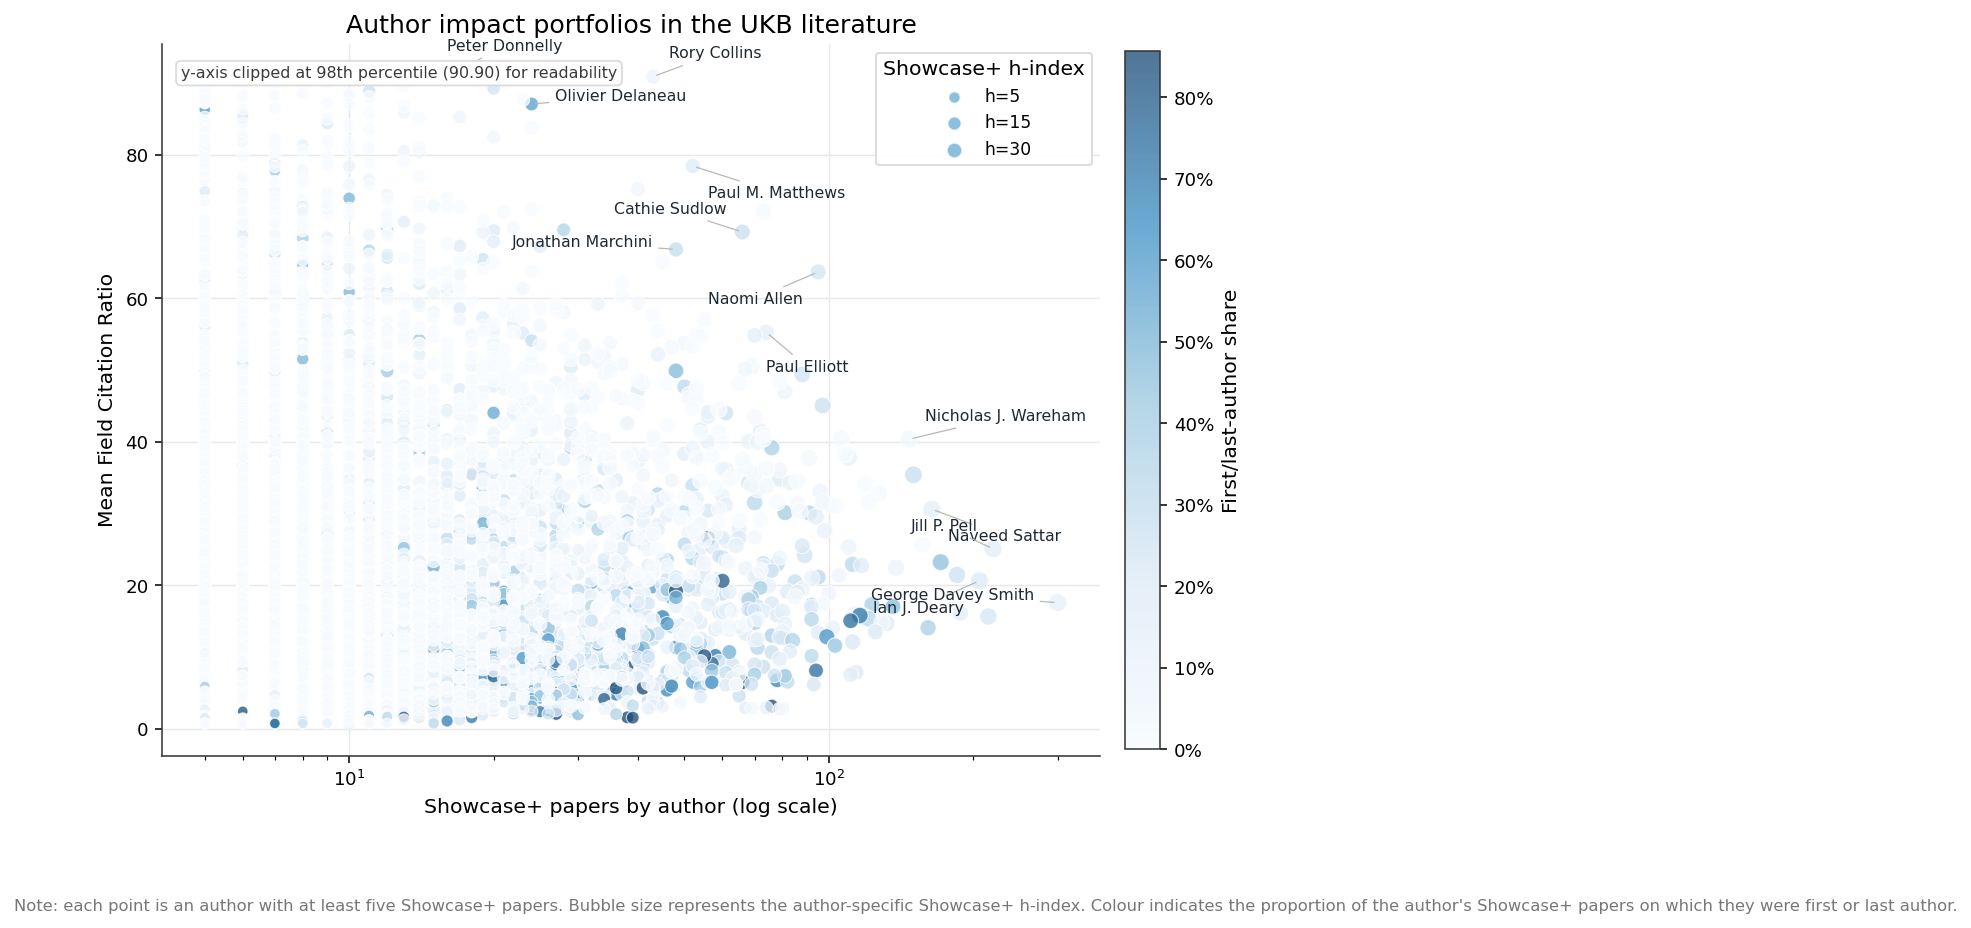

In [ ]:

# ============================================================
# 7. Candidate Fig. 3a/Supplement — Author impact portfolio map
# ============================================================
# This plot separates different forms of influence:
# output volume, normalised impact, h-index and leadership contribution.

portfolio = author_summary[author_summary["showcase_paper_count"] >= 5].copy()
portfolio = portfolio.replace([np.inf, -np.inf], np.nan)
portfolio = portfolio[portfolio["mean_impact_metric"].notna()].copy()

if portfolio.empty:
    raise ValueError("No recurrent authors with valid impact metrics were found.")

# Axes and aesthetics.
portfolio["x_papers"] = portfolio["showcase_paper_count"].astype(float)
portfolio["y_impact"] = portfolio["mean_impact_metric"].astype(float)
portfolio["bubble_size"] = 22 + 7.5 * np.sqrt(portfolio["showcase_h_index"].clip(lower=0))
portfolio["colour_value"] = portfolio["leadership_share"].clip(lower=0, upper=1)

# Winsorise y for the view, but keep original values in the table.
y_upper = np.nanpercentile(portfolio["y_impact"], 98)
y_lower = max(0, np.nanpercentile(portfolio["y_impact"], 1))
portfolio["y_impact_plot"] = portfolio["y_impact"].clip(lower=y_lower, upper=y_upper)

# Label a transparent set of influential / frontier authors.
label_candidates = pd.concat([
    portfolio.nlargest(8, "ukb_influence_score"),
    portfolio.nlargest(5, "showcase_paper_count"),
    portfolio.nlargest(5, "mean_impact_metric"),
    portfolio.nlargest(5, "showcase_h_index"),
]).drop_duplicates("author_key")
label_candidates = label_candidates.nlargest(14, "ukb_influence_score")

portfolio.to_csv(TABLE_DIR / "fig_author_impact_portfolio_all_recurrent_authors.csv", index=False)
label_candidates[["author_name", "showcase_paper_count", "mean_impact_metric", "showcase_h_index", "leadership_share", "ukb_influence_score"]].to_csv(
    TABLE_DIR / "fig_author_impact_portfolio_labelled_authors.csv", index=False
)

display(label_candidates[["author_name", "showcase_paper_count", "mean_impact_metric", "showcase_h_index", "leadership_share", "ukb_influence_score"]])

fig, ax = plt.subplots(figsize=(9.2, 6.6))

sc = ax.scatter(
    portfolio["x_papers"],
    portfolio["y_impact_plot"],
    s=portfolio["bubble_size"],
    c=portfolio["colour_value"],
    cmap=blue_cmap,
    vmin=0,
    vmax=min(1, max(0.35, portfolio["colour_value"].quantile(0.98))),
    alpha=0.78,
    edgecolor="white",
    linewidth=0.55,
)

ax.set_xscale("log")
ax.set_xlabel("Showcase+ papers by author (log scale)")
ax.set_ylabel(f"Mean {IMPACT_LABEL}")
ax.set_title("Author impact portfolios in the UKB literature")
ax.grid(axis="both", color="#E8E8E8", linewidth=0.75)
ax.set_axisbelow(True)

# Labels with alternating offsets to reduce overplotting without external dependencies.
offsets = [(8, 8), (8, -10), (-8, 8), (-8, -10), (12, 0), (-12, 0), (0, 12), (0, -14)]
for k, (_, r) in enumerate(label_candidates.iterrows()):
    dx, dy = offsets[k % len(offsets)]
    ax.annotate(
        r["author_name"],
        xy=(r["x_papers"], r["y_impact_plot"]),
        xytext=(dx, dy),
        textcoords="offset points",
        ha="left" if dx >= 0 else "right",
        va="bottom" if dy >= 0 else "top",
        fontsize=8.1,
        color=COLOUR["ink"],
        arrowprops=dict(arrowstyle="-", color=COLOUR["grey_mid"], lw=0.65, shrinkA=1, shrinkB=2),
    )

# Bubble-size legend.
legend_h = [5, 15, 30]
legend_handles = [
    ax.scatter([], [], s=22 + 7.5 * np.sqrt(h), facecolor=COLOUR["blue_mid"], edgecolor="white", alpha=0.78, label=f"h={h}")
    for h in legend_h
]
leg1 = ax.legend(handles=legend_handles, title="Showcase+ h-index", loc="upper right", frameon=True, framealpha=0.95)
leg1.get_frame().set_edgecolor("#DDDDDD")
ax.add_artist(leg1)

cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.025)
cbar.set_label("First/last-author share")
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# If values were clipped, show a small note inside the axes.
if (portfolio["y_impact"] > y_upper).any():
    ax.text(
        0.02,
        0.97,
        f"y-axis clipped at 98th percentile ({y_upper:.2f}) for readability",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.2,
        color=COLOUR["grey_dark"],
        bbox=dict(facecolor="white", edgecolor="#DDDDDD", boxstyle="round,pad=0.30"),
    )

fig.text(
    0.01,
    -0.045,
    (
        "Note: each point is an author with at least five Showcase+ papers. "
        "Bubble size represents the author-specific Showcase+ h-index. "
        "Colour indicates the proportion of the author's Showcase+ papers on which they were first or last author."
    ),
    ha="left",
    va="top",
    fontsize=8.4,
    color=COLOUR["grey"],
)

save_fig(fig, "fig_author_impact_portfolio_map")
plt.show()


,author_name,ukb_influence_score,showcase_paper_count,fractional_paper_credit,fractional_citation_credit,showcase_h_index,mean_impact_metric,fractional_top_decile_credit,leadership_share,active_span_years
0,Rory Collins,98.596703,43,2.718020,1606.181951,24,107.889535,1.127735,0.093023,11
1,Paul M. Matthews,98.583106,52,5.133639,1093.157300,28,78.443846,0.664220,0.192308,10
2,Cathie Sudlow,98.568852,66,5.722479,1661.836522,36,69.244545,1.800600,0.272727,11
3,Naomi Allen,98.511443,95,11.547227,2233.834445,37,63.671789,2.105634,0.242105,11
4,Olivier Delaneau,98.452763,24,3.699536,849.386370,14,87.086667,0.967949,0.583333,10
5,Jonathan Marchini,98.437356,48,5.452453,1138.742035,26,66.806042,1.044215,0.291667,10
6,Peter Donnelly,98.365109,16,1.513901,667.681256,12,121.383125,0.723390,0.312500,9
7,Paul Elliott,98.293760,74,5.291627,982.762313,43,55.260676,0.907958,0.135135,10
8,John Gallacher,98.270949,70,9.159059,1082.804805,33,54.848143,0.851125,0.142857,11
9,Jian Yang,98.195306,88,8.206608,1366.705301,46,49.390909,2.110689,0.250000,10


Saved: [previous-local-project]/showcase_plus_author_impact_figures_production/figures/fig_author_influence_fingerprint_heatmap.pdf


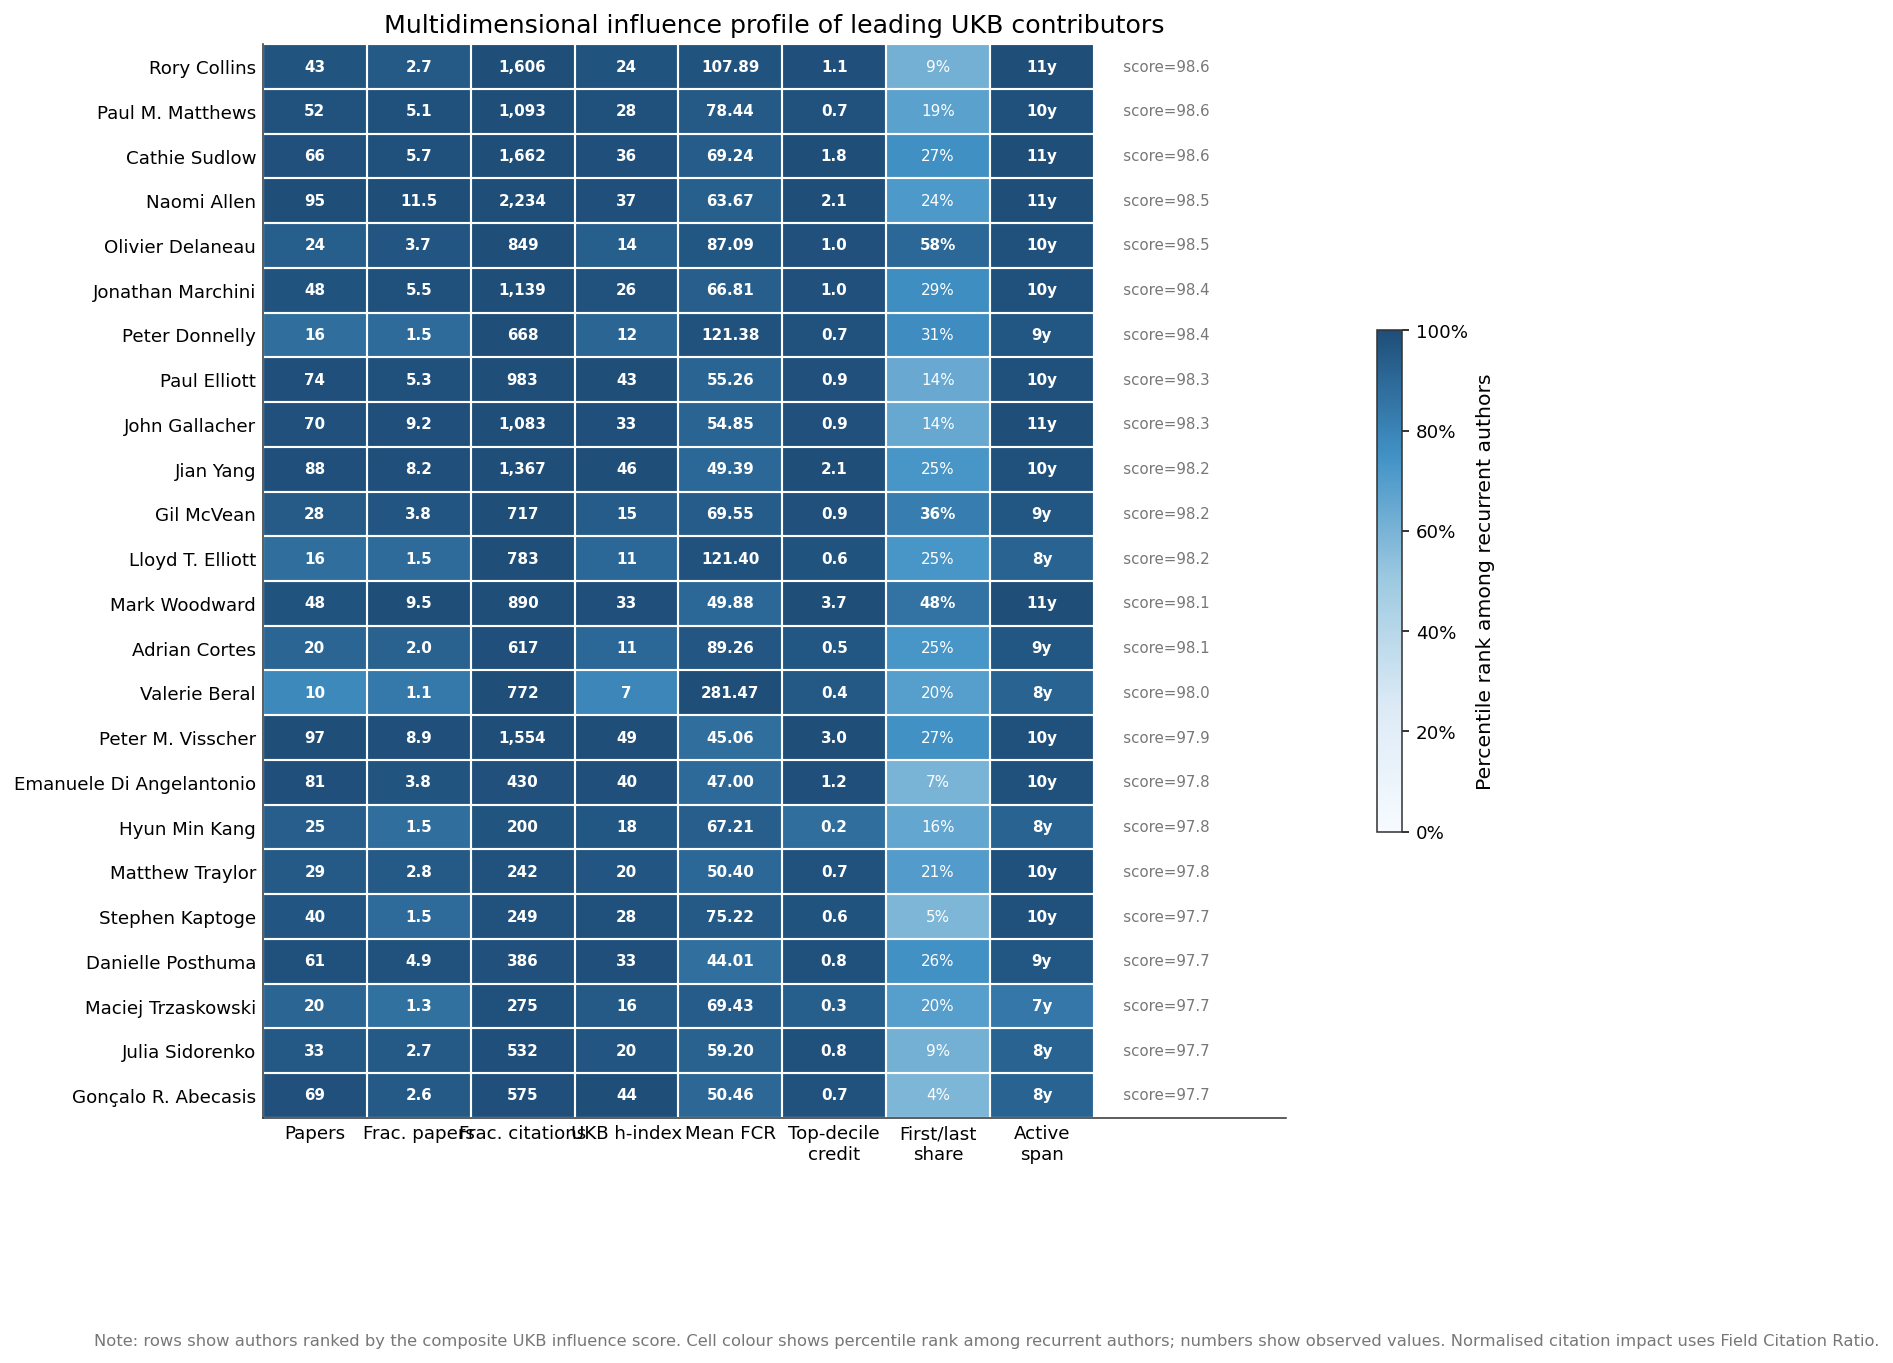

In [ ]:

# ============================================================
# 8. Supplement candidate — Influential-author fingerprint heatmap
# ============================================================
# Dense, paper-ready replacement for a simple top-author leaderboard.
# Rows are authors; columns show the dimensions that make them influential.

fingerprint_source = author_summary[author_summary["showcase_paper_count"] >= 3].copy()
if fingerprint_source.empty:
    fingerprint_source = author_summary.copy()

top_n = 24
fingerprint = author_summary.head(top_n).copy()

metric_specs = [
    ("showcase_paper_count", "Papers", lambda x: f"{int(x):,}"),
    ("fractional_paper_credit", "Frac. papers", lambda x: f"{x:.1f}"),
    ("fractional_citation_credit", "Frac. citations", lambda x: f"{x:,.0f}"),
    ("showcase_h_index", "UKB h-index", lambda x: f"{int(x):,}"),
    ("mean_impact_metric", f"Mean {IMPACT_SHORT}", lambda x: f"{x:.2f}"),
    ("fractional_top_decile_credit", "Top-decile\ncredit", lambda x: f"{x:.1f}"),
    ("leadership_share", "First/last\nshare", lambda x: f"{100*x:.0f}%"),
    ("active_span_years", "Active\nspan", lambda x: f"{int(x)}y"),
]

# Colour intensity is based on percentile rank among recurrent authors, not only among the displayed top authors.
norm_matrix = []
raw_text = []
for col, label, fmt in metric_specs:
    ranks = pct_rank_safe(fingerprint_source[col])
    rank_map = pd.Series(ranks.values, index=fingerprint_source["author_key"])
    vals_norm = fingerprint["author_key"].map(rank_map).fillna(0).values
    norm_matrix.append(vals_norm)
    raw_text.append([fmt(v) if pd.notna(v) else "" for v in fingerprint[col].values])

norm_matrix = np.array(norm_matrix).T
raw_text = np.array(raw_text).T

fingerprint[["author_name", "ukb_influence_score"] + [m[0] for m in metric_specs]].to_csv(
    TABLE_DIR / "fig_author_influence_fingerprint_top_authors.csv",
    index=False,
)

display(fingerprint[["author_name", "ukb_influence_score"] + [m[0] for m in metric_specs]].head(top_n))

fig_height = max(7.2, 0.34 * len(fingerprint) + 1.8)
fig, ax = plt.subplots(figsize=(10.5, fig_height))

im = ax.imshow(norm_matrix, aspect="auto", cmap=blue_cmap, vmin=0, vmax=1)

ax.set_yticks(np.arange(len(fingerprint)))
ax.set_yticklabels(fingerprint["author_name"].fillna(""))
ax.set_xticks(np.arange(len(metric_specs)))
ax.set_xticklabels([m[1] for m in metric_specs], rotation=0, ha="center")

# Numeric labels inside cells.
for i in range(norm_matrix.shape[0]):
    for j in range(norm_matrix.shape[1]):
        val = norm_matrix[i, j]
        ax.text(
            j,
            i,
            raw_text[i, j],
            ha="center",
            va="center",
            fontsize=7.8,
            color="white" if val > 0.58 else COLOUR["ink"],
            fontweight="bold" if val > 0.78 else "normal",
        )

# Thin white cell boundaries.
ax.set_xticks(np.arange(-0.5, len(metric_specs), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(fingerprint), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.1)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

ax.set_title("Multidimensional influence profile of leading UKB contributors")
ax.set_xlim(-0.5, len(metric_specs) + 1.35)

# Add influence score as a right-side annotation.
for i, (_, r) in enumerate(fingerprint.iterrows()):
    ax.text(
        len(metric_specs) - 0.35,
        i,
        f"   score={r['ukb_influence_score']:.1f}",
        ha="left",
        va="center",
        fontsize=7.7,
        color=COLOUR["grey"],
    )

cbar = fig.colorbar(im, ax=ax, fraction=0.022, pad=0.08)
cbar.set_label("Percentile rank among recurrent authors")
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))

fig.text(
    0.01,
    -0.045,
    (
        "Note: rows show authors ranked by the composite UKB influence score. "
        "Cell colour shows percentile rank among recurrent authors; numbers show observed values. "
        f"Normalised citation impact uses {IMPACT_LABEL}."
    ),
    ha="left",
    va="top",
    fontsize=8.4,
    color=COLOUR["grey"],
)

save_fig(fig, "fig_author_influence_fingerprint_heatmap")
plt.show()
